# **Product Recommendation System - Amazon Product Reviews**

# Part 1 - Business Problem / Problema de Negócio

**[EN]**
Amazon is one of the world's largest e-commerce platforms, hosting millions of products
across hundreds of categories. With such a vast catalog, customers often struggle to
discover products that match their preferences, leading to poor shopping experiences,
lower engagement, and reduced conversion rates.

**[PT]**
A Amazon é uma das maiores plataformas de e-commerce do mundo, com milhões de produtos
em centenas de categorias. Com um catálogo tão vasto, os clientes frequentemente têm
dificuldade em descobrir produtos que correspondam às suas preferências, resultando em
experiências de compra ruins, menor engajamento e taxas de conversão reduzidas.

**Objective / Objetivo**

**[EN]**
Build a **Content-Based Product Recommendation System** using **K-Nearest Neighbors (KNN)**
with **Cosine Similarity** as the distance metric, capable of recommending the most similar
products to a given item based on customer reviews, ratings, and product metadata.

**[PT]**
Construir um **Sistema de Recomendação de Produtos baseado em Conteúdo** utilizando
**K-Nearest Neighbors (KNN)** com **Similaridade Cosseno** como métrica de distância,
capaz de recomendar os produtos mais similares a um item consultado, com base em
avaliações de clientes, ratings e metadados do produto.

**Business Questions / Perguntas de Negócio**

**[EN]**
- Given a product a customer is currently viewing, which other products are most similar to it?
- Which products share the closest review profile to a recently purchased item?
- How can Amazon surface relevant recommendations without relying on collaborative user data?

**[PT]**
- Dado um produto que o cliente está visualizando, quais outros produtos são mais similares a ele?
- Quais produtos compartilham o perfil de avaliações mais próximo de um item recém-comprado?
- Como a Amazon pode apresentar recomendações relevantes sem depender de dados colaborativos de usuários?

**Proposed Solution / Solução Proposta**

**[EN]**
| Step | Technique | Purpose |
|------|-----------|---------|
| Text Vectorization | TF-IDF (unigrams + bigrams) | Capture review language patterns |
| Numerical Features | MinMaxScaler | Normalize rating, helpful votes, review count |
| Feature Matrix | Sparse `hstack` | Combine text + numerical into a single matrix |
| Similarity Model | KNN with `metric='cosine'` | Find the K most similar products |
| Output | Ranked recommendation list | Return top-K products with similarity scores |

**[PT]**
| Etapa | Técnica | Finalidade |
|-------|---------|------------|
| Vetorização de Texto | TF-IDF (unigramas + bigramas) | Capturar padrões de linguagem nos reviews |
| Features Numéricas | MinMaxScaler | Normalizar rating, votos úteis e contagem de reviews |
| Matriz de Features | Sparse `hstack` | Combinar texto + numérico em uma única matriz |
| Modelo de Similaridade | KNN com `metric='cosine'` | Encontrar os K produtos mais similares |
| Saída | Lista rankeada de recomendações | Retornar top-K produtos com scores de similaridade |

**Why Cosine Similarity? / Por que Similaridade Cosseno?**

**[EN]**
Cosine Similarity measures the angle between two vectors in the feature space,
ignoring their magnitude. This is ideal for TF-IDF sparse matrices because a product
with many reviews will not artificially dominate over a product with fewer reviews —
only the direction (content profile) matters.

**[PT]**
A Similaridade Cosseno mede o ângulo entre dois vetores no espaço de features,
ignorando sua magnitude. Isso é ideal para matrizes esparsas TF-IDF porque um produto
com muitos reviews não irá dominar artificialmente sobre um produto com menos reviews —
apenas a direção (perfil de conteúdo) é o que importa.

> **Formula / Fórmula:**
> $$\text{cosine\_similarity}(A, B) = \frac{A \cdot B}{\|A\| \cdot \|B\|}$$

**Success Metric / Métrica de Sucesso**

**[EN]**
- Average Cosine Similarity score among the top-5 recommended products ≥ 0.5
- Full catalog coverage: every product must receive at least 5 valid recommendations
- Recommendation diversity: recommended products must span at least 2 distinct categories

**[PT]**
- Score médio de Similaridade Cosseno entre os top-5 produtos recomendados ≥ 0.5
- Cobertura total do catálogo: todo produto deve receber pelo menos 5 recomendações válidas
- Diversidade das recomendações: os produtos recomendados devem abranger ao menos 2 categorias distintas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.neighbors import NearestNeighbors
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack, csr_matrix

warnings.filterwarnings("ignore")

# Part 2 - Database

In [3]:
df = pd.read_csv(
    r"C:\Users\rafae.RAFAEL_NOTEBOOK\OneDrive\Documentos\Deploy\prod\ML_System_recommendation_products_amazon_products\input\7817_1.csv",
    low_memory=False
)

# Load raw dataset and display basic structure for initial inspection
print(f"Shape: {df.shape}")

# Check missing values per column to plan cleaning strategy
print(f"\nNull values per column:\n{df.isnull().sum()}")

df.head(3)

Shape: (1597, 27)

Null values per column:
id                         0
asins                      0
brand                      0
categories                 0
colors                   823
dateAdded                  0
dateUpdated                0
dimension               1032
ean                      699
keys                       0
manufacturer             632
manufacturerNumber       695
name                       0
prices                     0
reviews.date             380
reviews.doRecommend     1058
reviews.numHelpful       697
reviews.rating           420
reviews.sourceURLs         0
reviews.text               0
reviews.title             17
reviews.userCity        1597
reviews.userProvince    1597
reviews.username          17
sizes                   1597
upc                      699
weight                   911
dtype: int64


,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,4.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader,NaN,NaN,Tedd Gardiner,NaN,NaN,205 grams


In [4]:
df.tail()

,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
1592,AVpfo9ukilAPnD_xfhuj,B00NO8JJZW,Amazon,"Amazon Devices & Accessories,Amazon Device Acc...",NaN,2016-04-02T14:40:43Z,2017-08-13T08:28:46Z,NaN,NaN,alexavoiceremoteforamazonfiretvfiretvstick/b00...,...,3.0,https://www.amazon.com/Alexa-Voice-Remote-Amaz...,This is not the same remote that I got for my ...,I would be disappointed with myself if i produ...,NaN,NaN,GregAmandawith4,NaN,NaN,4 ounces
1593,AVpfo9ukilAPnD_xfhuj,B00NO8JJZW,Amazon,"Amazon Devices & Accessories,Amazon Device Acc...",NaN,2016-04-02T14:40:43Z,2017-08-13T08:28:46Z,NaN,NaN,alexavoiceremoteforamazonfiretvfiretvstick/b00...,...,1.0,https://www.amazon.com/Alexa-Voice-Remote-Amaz...,I have had to change the batteries in this rem...,Battery draining remote!!!!,NaN,NaN,Amazon Customer,NaN,NaN,4 ounces
1594,AVpfo9ukilAPnD_xfhuj,B00NO8JJZW,Amazon,"Amazon Devices & Accessories,Amazon Device Acc...",NaN,2016-04-02T14:40:43Z,2017-08-13T08:28:46Z,NaN,NaN,alexavoiceremoteforamazonfiretvfiretvstick/b00...,...,1.0,https://www.amazon.com/Alexa-Voice-Remote-Amaz...,"Remote did not activate, nor did it connect to...",replacing an even worse remote. Waste of time,NaN,NaN,Amazon Customer,NaN,NaN,4 ounces
1595,AVpfo9ukilAPnD_xfhuj,B00NO8JJZW,Amazon,"Amazon Devices & Accessories,Amazon Device Acc...",NaN,2016-04-02T14:40:43Z,2017-08-13T08:28:46Z,NaN,NaN,alexavoiceremoteforamazonfiretvfiretvstick/b00...,...,3.0,https://www.amazon.com/Alexa-Voice-Remote-Amaz...,It does the job but is super over priced. I fe...,Overpriced,NaN,NaN,Meg Ashley,NaN,NaN,4 ounces
1596,AVpfo9ukilAPnD_xfhuj,B00NO8JJZW,Amazon,"Amazon Devices & Accessories,Amazon Device Acc...",NaN,2016-04-02T14:40:43Z,2017-08-13T08:28:46Z,NaN,NaN,alexavoiceremoteforamazonfiretvfiretvstick/b00...,...,1.0,https://www.amazon.com/Alexa-Voice-Remote-Amaz...,I ordered this item to replace the one that no...,I am sending all of this crap back to amazon a...,NaN,NaN,DIANE K,NaN,NaN,4 ounces


In [5]:
df.shape

(1597, 27)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1597 entries, 0 to 1596
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1597 non-null   object 
 1   asins                 1597 non-null   object 
 2   brand                 1597 non-null   object 
 3   categories            1597 non-null   object 
 4   colors                774 non-null    object 
 5   dateAdded             1597 non-null   object 
 6   dateUpdated           1597 non-null   object 
 7   dimension             565 non-null    object 
 8   ean                   898 non-null    float64
 9   keys                  1597 non-null   object 
 10  manufacturer          965 non-null    object 
 11  manufacturerNumber    902 non-null    object 
 12  name                  1597 non-null   object 
 13  prices                1597 non-null   object 
 14  reviews.date          1217 non-null   object 
 15  reviews.doRecommend  

In [7]:
df.dtypes

id                       object
asins                    object
brand                    object
categories               object
colors                   object
dateAdded                object
dateUpdated              object
dimension                object
ean                     float64
keys                     object
manufacturer             object
manufacturerNumber       object
name                     object
prices                   object
reviews.date             object
reviews.doRecommend      object
reviews.numHelpful      float64
reviews.rating          float64
reviews.sourceURLs       object
reviews.text             object
reviews.title            object
reviews.userCity        float64
reviews.userProvince    float64
reviews.username         object
sizes                   float64
upc                     float64
weight                   object
dtype: object

# **Part 3 - Pre-processing**

In [8]:
# Select only relevant columns for the recommendation system
cols = [
    "asins", "name", "brand", "categories",
    "reviews.text", "reviews.rating", "reviews.numHelpful"
]

# Drop rows without product id or review text since they are unusable
df = df[cols].dropna(subset=["asins", "reviews.text"])

# Convert rating and helpful votes to numeric, fill missing with 0
df["reviews.rating"]     = pd.to_numeric(df["reviews.rating"],     errors="coerce").fillna(0)
df["reviews.numHelpful"] = pd.to_numeric(df["reviews.numHelpful"], errors="coerce").fillna(0)

# Display shape and first 10 rows to validate cleaning result
print(f"Shape after cleaning: {df.shape}")
df.head(n=10)

Shape after cleaning: (1597, 7)


,asins,name,brand,categories,reviews.text,reviews.rating,reviews.numHelpful
0,B00QJDU3KY,Kindle Paperwhite,Amazon,"Amazon Devices,mazon.co.uk",I initially had trouble deciding between the p...,5.0,139.0
1,B00QJDU3KY,Kindle Paperwhite,Amazon,"Amazon Devices,mazon.co.uk",Allow me to preface this with a little history...,5.0,126.0
2,B00QJDU3KY,Kindle Paperwhite,Amazon,"Amazon Devices,mazon.co.uk",I am enjoying it so far. Great for reading. Ha...,4.0,69.0
3,B00QJDU3KY,Kindle Paperwhite,Amazon,"Amazon Devices,mazon.co.uk",I bought one of the first Paperwhites and have...,5.0,2.0
4,B00QJDU3KY,Kindle Paperwhite,Amazon,"Amazon Devices,mazon.co.uk",I have to say upfront - I don't like coroporat...,5.0,17.0
5,B00QJDU3KY,Kindle Paperwhite,Amazon,"Amazon Devices,mazon.co.uk","My previous kindle was a DX, this is my second...",0.0,0.0
6,B00QJDU3KY,Kindle Paperwhite,Amazon,"Amazon Devices,mazon.co.uk",Allow me to preface this with a little history...,0.0,0.0
7,B00QJDU3KY,Kindle Paperwhite,Amazon,"Amazon Devices,mazon.co.uk",Just got mine right now. Looks the same as the...,0.0,0.0
8,B00QJDU3KY,Kindle Paperwhite,Amazon,"Amazon Devices,mazon.co.uk",I initially had trouble deciding between the p...,0.0,0.0
9,B00QJDU3KY,Kindle Paperwhite,Amazon,"Amazon Devices,mazon.co.uk",I am enjoying it so far. Great for reading. Ha...,0.0,0.0


In [9]:
# Aggregate all reviews by product (asins) to build one row per product
df_products = df.groupby("asins").agg(
    name          = ("name",               "first"),   # Keep first product name found
    brand         = ("brand",              "first"),   # Keep first brand found
    categories    = ("categories",         "first"),   # Keep first category found
    avg_rating    = ("reviews.rating",     "mean"),    # Average rating across all reviews
    total_helpful = ("reviews.numHelpful", "sum"),     # Total helpful votes across all reviews
    review_count  = ("reviews.text",       "count"),   # Number of reviews per product
    all_reviews   = ("reviews.text",       lambda x: " ".join(x.dropna().astype(str)))  # Concatenate all review texts
).reset_index()

# Display total unique products after aggregation
print(f"Total unique products: {len(df_products)}")
df_products.head(n=10)

Total unique products: 54


,asins,name,brand,categories,avg_rating,total_helpful,review_count,all_reviews
0,B002Y27P3M,Kindle Keyboard,Amazon,"Kindle Store,Amazon Devices,Electronics",0.750000,0.0,32,The Kindle is my first e-ink reader. I own an ...
1,"B008GG93YE,B00LWHUBPO,B0051QYGXA",Kindle,Amazon,"Amazon Devices,Kindle Store",0.950000,1105.0,20,I got my first Kindle. This is a nice ebook re...
2,"B008GGCAVM,B00DOPNMVM","Kindle Fire HD 7""",Amazon,"Amazon Devices,Kindle Store",1.292683,2354.0,41,I've been an iPad user since the original came...
3,B00CX5P8FC,Amazon Fire TV,Amazon,"Categories,Amazon Devices,Electronics Features...",1.114458,0.0,166,An Amazon.com official commented on this revie...
4,B00DOPNK14,Kindle Paperwhite,Amazon,"Amazon Devices,Kindle Store,Kindle Accessories",4.500000,2354.0,4,This is the fifth e-ink Kindle reader that I'v...
5,B00DOPNLJ0,"Kindle Fire HDX 8.9""",Amazon,Amazon Devices,1.209302,876.0,43,Updated 12/8/2014One year in...This review is ...
6,"B00DOPNO4M,B00BWYQ9YE,B00CYQPMJC,B00CUU1CGY,B0...","Kindle Fire HDX 7""",Amazon,"Amazon Devices,Kindle Store,buy a kindle",1.442857,1675.0,70,Update on Dec 23 2013 - Please scroll to the v...
7,B00DU15MU4,Certified Refurbished Amazon Fire TV (Previous...,Amazon,"Categories,Amazon Devices,Streaming Media Players",1.315789,0.0,38,"Having received my Fire TV today, I've been tr..."
8,B00HX0SRXW,Amazon Premium Headphones,Amazon,"Amazon Devices,Corded Headsets,Electronics Fea...",2.323308,2174.0,133,While I've purchased items from Amazon for yea...
9,B00K5W9WZW,Moshi Anti-Glare No Bubble Screen Protector fo...,Moshi,"Cell Phones & Accessories,Accessories,Screen P...",3.333333,59.0,12,"UPDATE: July 6, 2015I'm reducing my rating to ..."


# **Part 4 - Vectorization TF-IDF**

In [10]:
# Vectorize concatenated review texts using TF-IDF with unigrams and bigrams
tfidf = TfidfVectorizer(
    max_features = 500,  # Limit vocabulary to top 500 most important terms
    stop_words   = "english",  # Remove common english stop words
    ngram_range  = (1, 2),  # Consider single words and two-word combinations
    min_df       = 2  # Ignore terms that appear in less than 2 products
)

# Fit and transform all review texts into a sparse TF-IDF matrix
X_text = tfidf.fit_transform(df_products["all_reviews"])

# Display resulting matrix shape: rows = products, columns = TF-IDF features
print(f"TF-IDF matrix shape: {X_text.shape}")

tfidf

TF-IDF matrix shape: (54, 500)


TfidfVectorizer(max_features=500, min_df=2, ngram_range=(1, 2),
                stop_words='english')

# **Part 5 - Normalization**

In [11]:
# Normalize numerical features to [0, 1] range to match TF-IDF scale
scaler = MinMaxScaler()

# Extract numerical features from aggregated product dataframe
num_features = df_products[["avg_rating", "total_helpful", "review_count"]].values

# Apply MinMaxScaler and convert to sparse matrix for efficient hstack with TF-IDF
X_num = csr_matrix(scaler.fit_transform(num_features))

# Display shape: rows = products, columns = 3 numerical features
print(f"Numerical features shape: {X_num.shape}")

scaler

Numerical features shape: (54, 3)


MinMaxScaler()

In [12]:
# COMBINE TEXT + NUMERICAL INTO FINAL FEATURE MATRIX

X = hstack([X_text, X_num])
print(f"Final feature matrix shape: {X.shape}")

Final feature matrix shape: (54, 503)


# Section A) Machine learning

# Part 6 - Model K-NN

In [14]:
# Search for the optimal number of neighbors K by evaluating F1@K across all products
k_range       = range(2, 21)
prec_scores   = []
recall_scores = []
f1_scores     = []
hit_scores    = []

for k in k_range:

    p_list, r_list, f_list, h_list = [], [], [], []

    for i in range(len(df_products)):

        # Get feature vector for current product
        product_vec  = X[i]

        # Find k+1 neighbors to exclude the product itself from results
        dists, idxs  = knn_model.kneighbors(product_vec, n_neighbors=k + 1)
        idxs         = idxs.flatten()

        # Build list of recommended asins excluding the query product
        rec_asins = [
            df_products.iloc[idx]["asins"]
            for idx in idxs
            if df_products.index[idx] != df_products.index[i]
        ][:k]

        # Intersect recommendations with ground truth relevant products
        rec_set  = set(rec_asins)
        rel_hits = rec_set & relevant_products

        # Compute individual metrics for current product and K
        prec = len(rel_hits) / k
        rec  = len(rel_hits) / len(relevant_products) if len(relevant_products) > 0 else 0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
        hit  = 1 if len(rel_hits) > 0 else 0

        p_list.append(prec)
        r_list.append(rec)
        f_list.append(f1)
        h_list.append(hit)

    # Compute macro average across all products for current K
    prec_scores.append(np.mean(p_list))
    recall_scores.append(np.mean(r_list))
    f1_scores.append(np.mean(f_list))
    hit_scores.append(np.mean(h_list))

# Select best K based on highest F1@K score
best_k  = list(k_range)[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print(f"Best n_neighbors : {best_k}")
print(f"Best F1@K        : {best_f1:.4f}")
print(f"Precision@K      : {prec_scores[best_k - 2]:.4f}")
print(f"Recall@K         : {recall_scores[best_k - 2]:.4f}")
print(f"Hit Rate@K       : {hit_scores[best_k - 2]:.4f}")

NameError: name 'knn_model' is not defined

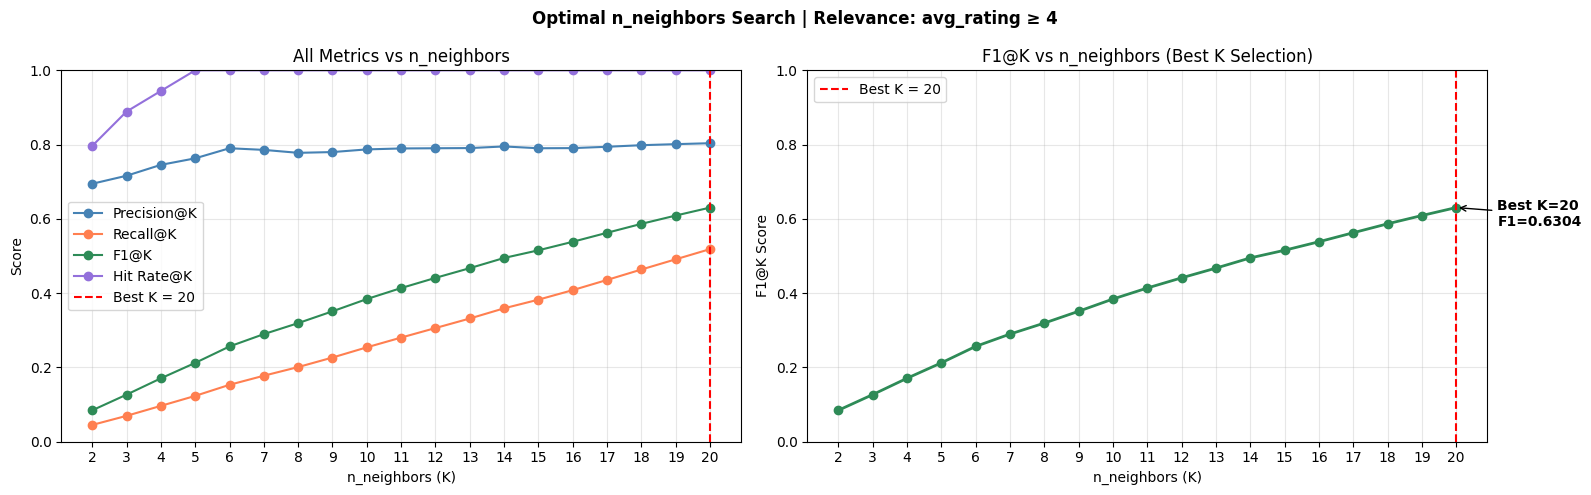

In [35]:
# Create side by side plots to visualize optimal K search results
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Optimal n_neighbors Search | Relevance: avg_rating ≥ 4", fontweight="bold")

# Plot all four metrics across K range to compare their behavior
axes[0].plot(k_range, prec_scores,   marker="o", label="Precision@K", color="steelblue")
axes[0].plot(k_range, recall_scores, marker="o", label="Recall@K",    color="coral")
axes[0].plot(k_range, f1_scores,     marker="o", label="F1@K",        color="seagreen")
axes[0].plot(k_range, hit_scores,    marker="o", label="Hit Rate@K",  color="mediumpurple")

# Mark the best K with a vertical dashed line
axes[0].axvline(best_k, color="red", linestyle="--", linewidth=1.5, label=f"Best K = {best_k}")
axes[0].set_title("All Metrics vs n_neighbors")
axes[0].set_xlabel("n_neighbors (K)")
axes[0].set_ylabel("Score")
axes[0].set_xticks(list(k_range))
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Zoom into F1@K curve to highlight the peak with annotation
axes[1].plot(k_range, f1_scores, marker="o", color="seagreen", linewidth=2)

# Vertical line marking the best K found by F1 maximization
axes[1].axvline(best_k, color="red", linestyle="--", linewidth=1.5, label=f"Best K = {best_k}")

# Annotate the peak point with best K value and F1 score
axes[1].annotate(
    f"Best K={best_k}\nF1={best_f1:.4f}",
    xy         = (best_k, best_f1),
    xytext     = (best_k + 1.2, best_f1 - 0.05),
    arrowprops = dict(arrowstyle="->", color="black"),
    fontsize   = 10,
    fontweight = "bold"
)
axes[1].set_title("F1@K vs n_neighbors (Best K Selection)")
axes[1].set_xlabel("n_neighbors (K)")
axes[1].set_ylabel("F1@K Score")
axes[1].set_xticks(list(k_range))
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# Retrain final KNN model using the optimal number of neighbors found by F1@K maximization
knn_model = NearestNeighbors(n_neighbors = 20,   # Optimal K selected from grid search
                             metric = "cosine", # Cosine similarity as distance metric for sparse TF-IDF vectors
                             algorithm = "brute",  # Brute force required for sparse matrix compatibility
                             n_jobs = -1        # Use all available CPU cores for parallel computation
                            )

# Fit model on the combined TF-IDF and numerical feature matrix
knn_model.fit(X)

print(f"KNN retrained with optimal n_neighbors = {20}")
print(f"Metric: cosine | algorithm: brute")

knn_model

KNN retrained with optimal n_neighbors = 20
Metric: cosine | algorithm: brute


NearestNeighbors(algorithm='brute', metric='cosine', n_jobs=-1, n_neighbors=20)

# Part 7 - Recommendations Product

In [18]:
# Define the product name query to search in the catalog
query = "Fire"

# Filter products whose name contains the query string (case insensitive)
mask = df_products["name"].str.contains(query, case=False, na=False)

# Get the dataframe index of the first matched product
product_idx = df_products[mask].index[0]

# Retrieve the full product row for the selected product
product_row = df_products.loc[product_idx]

# Display selected product details before generating recommendations
print(f"Query product : {product_row['name']}")
print(f"Brand         : {product_row['brand']}")
print(f"Category      : {product_row['categories']}")
print(f"Avg Rating    : {product_row['avg_rating']:.2f}")
print(f"Review Count  : {product_row['review_count']}")

Query product : Kindle Fire HD 7"
Brand         : Amazon
Category      : Amazon Devices,Kindle Store
Avg Rating    : 1.29
Review Count  : 41


In [19]:
# Define the product name query to search in the catalog
query = "Fire HD 7 Tablet"

# Filter products whose name contains the query string (case insensitive)
mask = df_products["name"].str.contains(query, case=False, na=False)

# Get the dataframe index of the first matched product
product_idx = df_products[mask].index[0]

# Retrieve the full product row for the selected product
product_row = df_products.loc[product_idx]

# Display selected product details before generating recommendations
print(f"Query product : {product_row['name']}")
print(f"Brand         : {product_row['brand']}")
print(f"Category      : {product_row['categories']}")
print(f"Avg Rating    : {product_row['avg_rating']:.2f}")
print(f"Review Count  : {product_row['review_count']}")

Query product : Fire HD 7 Tablet
Brand         : Amazon
Category      : Amazon Devices
Avg Rating    : 5.00
Review Count  : 4


In [21]:
# Get the positional index of the query product in the feature matrix
product_vector = X[df_products.index.get_loc(product_idx)]

# Find K nearest neighbors using the trained KNN model
distances, indices = knn_model.kneighbors(product_vector, n_neighbors=20 + 1)

# Convert cosine distances to similarity scores (similarity = 1 - distance)
similarities = 1 - distances.flatten()
neighbor_indices = indices.flatten()

print(f"Distances   : {distances.flatten()}")
print(f"Similarities: {similarities}")

Distances   : [4.44089210e-16 2.19319937e-01 2.98163660e-01 3.01933669e-01
 3.01933669e-01 3.05021957e-01 3.07542561e-01 3.13360712e-01
 3.13360712e-01 3.13360712e-01 3.15305450e-01 3.27911351e-01
 3.30338432e-01 3.31421071e-01 3.40862926e-01 3.43021144e-01
 3.50388928e-01 3.59279937e-01 3.71577810e-01 3.89779580e-01
 4.07666428e-01]
Similarities: [1.         0.78068006 0.70183634 0.69806633 0.69806633 0.69497804
 0.69245744 0.68663929 0.68663929 0.68663929 0.68469455 0.67208865
 0.66966157 0.66857893 0.65913707 0.65697886 0.64961107 0.64072006
 0.62842219 0.61022042 0.59233357]


In [22]:
# Build recommendations list excluding the query product itself
results = []

for sim, idx in zip(similarities, neighbor_indices):

    # Skip the query product if it appears in its own neighbor list
    if df_products.index[idx] == product_idx:
        continue

    row = df_products.iloc[idx]

    # Append neighbor product details and similarity score to results
    results.append({
        "product"          : row["name"],
        "brand"            : row["brand"],
        "category"         : row["categories"],
        "avg_rating"       : round(row["avg_rating"], 2),
        "review_count"     : row["review_count"],
        "cosine_similarity": round(sim, 4)
    })

# Convert results to dataframe and keep only top 5 recommendations
recommendations = pd.DataFrame(results).head(5)

print("\n=== TOP 5 RECOMMENDATIONS ===")
display(recommendations)


=== TOP 5 RECOMMENDATIONS ===


,product,brand,category,avg_rating,review_count,cosine_similarity
0,Fire HDX 8.9 Tablet,Amazon,Amazon Devices,4.33,3,0.7807
1,Fire HD 8 Tablet with Alexa,Amazon,"Electronics,Amazon Devices",4.67,3,0.7018
2,Fire HD 10 Tablet with Alexa,Amazon,Amazon Devices,4.50,4,0.6981
3,Fire HD 10 Tablet with Alexa,Amazon,Amazon Devices,4.50,4,0.6981
4,All-New Fire 7 Tablet with Alexa,Amazon,"Electronics,Amazon Devices",4.75,4,0.6950


In [ ]:
# Receive product name from user input and strip leading/trailing whitespace
query   = input("Enter product name (or part of it): ").strip()

# Filter catalog for products matching the query string (case insensitive)
mask    = df_products["name"].str.contains(query, case=False, na=False)
matches = df_products[mask].reset_index(drop=True)

# Display all matched products so user can select the correct one
print(f"\nProducts found for '{query}': {len(matches)}")
display(matches[["asins", "name", "brand", "categories", "avg_rating", "review_count"]])

In [53]:
query = input("Enter product name (or part of it): ").strip()

mask    = df_products["name"].str.contains(query, case=False, na=False)
matches = df_products[mask].reset_index(drop=True)

print(f"\nProducts found for '{query}': {len(matches)}")
display(matches[["asins", "name", "brand", "categories", "avg_rating", "review_count"]])

Enter product name (or part of it):  Kindle 



Products found for 'Kindle': 21


,asins,name,brand,categories,avg_rating,review_count
0,B002Y27P3M,Kindle Keyboard,Amazon,"Kindle Store,Amazon Devices,Electronics",0.750000,32
1,"B008GG93YE,B00LWHUBPO,B0051QYGXA",Kindle,Amazon,"Amazon Devices,Kindle Store",0.950000,20
2,"B008GGCAVM,B00DOPNMVM","Kindle Fire HD 7""",Amazon,"Amazon Devices,Kindle Store",1.292683,41
3,B00DOPNK14,Kindle Paperwhite,Amazon,"Amazon Devices,Kindle Store,Kindle Accessories",4.500000,4
4,B00DOPNLJ0,"Kindle Fire HDX 8.9""",Amazon,Amazon Devices,1.209302,43
5,"B00DOPNO4M,B00BWYQ9YE,B00CYQPMJC,B00CUU1CGY,B0...","Kindle Fire HDX 7""",Amazon,"Amazon Devices,Kindle Store,buy a kindle",1.442857,70
6,B00KDRQEYQ,Certified Refurbished Kindle E-reader,Amazon,Amazon Devices,2.333333,6
7,B00KSR13CE,Kindle Paperwhite,Amazon,"Amazon Devices,Kindle Accessories",1.083333,12
8,B00OQVZDJM,Kindle Paperwhite E-reader - Black,Amazon,Amazon Devices,5.000000,3
9,B00PD81ETU,Certified Refurbished Kindle Voyage E-reader w...,Amazon,Amazon Devices,4.333333,3


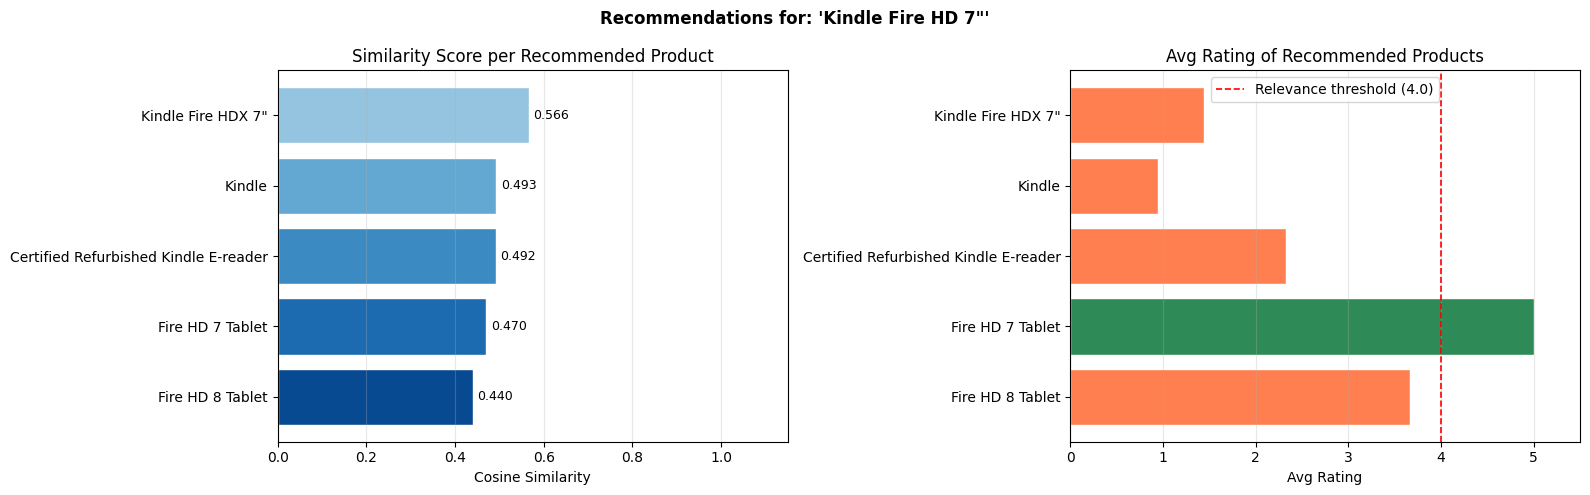

In [47]:
# Generate color gradient for similarity bars from light to dark blue
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(recommendations)))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f"Recommendations for: '{product_row['name'][:50]}'", fontweight="bold")

# Plot horizontal bars with cosine similarity scores per recommended product
bars = axes[0].barh(
    recommendations["product"].str[:40],
    recommendations["cosine_similarity"],
    color     = colors,
    edgecolor = "white"
)

# Annotate each bar with its similarity score value
for bar, val in zip(bars, recommendations["cosine_similarity"]):
    axes[0].text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va       = "center",
        fontsize = 9
    )

axes[0].set_xlabel("Cosine Similarity")
axes[0].set_title("Similarity Score per Recommended Product")
axes[0].set_xlim(0, 1.15)
axes[0].invert_yaxis()
axes[0].grid(alpha=0.3, axis="x")

# Color bars green if avg rating meets relevance threshold, red otherwise
rating_colors = [
    "seagreen" if r >= 4.0 else "coral"
    for r in recommendations["avg_rating"]
]

# Plot horizontal bars with average rating per recommended product
axes[1].barh(
    recommendations["product"].str[:40],
    recommendations["avg_rating"],
    color     = rating_colors,
    edgecolor = "white"
)

# Draw vertical line at rating 4.0 to indicate relevance threshold
axes[1].axvline(4.0, color="red", linestyle="--", linewidth=1.2, label="Relevance threshold (4.0)")
axes[1].set_xlabel("Avg Rating")
axes[1].set_title("Avg Rating of Recommended Products")
axes[1].set_xlim(0, 5.5)
axes[1].invert_yaxis()
axes[1].legend()
axes[1].grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

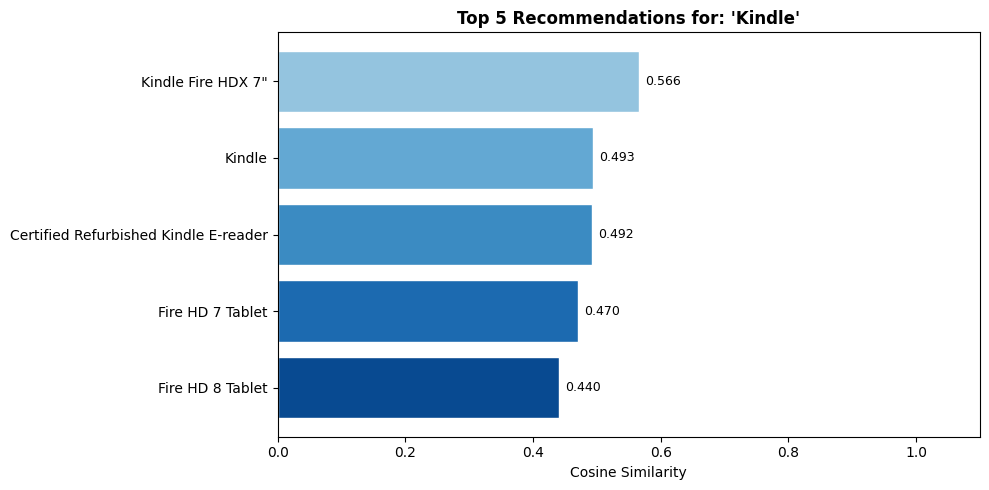

In [54]:
# Generate color gradient for similarity bars from light to dark blue
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(recommendations)))

plt.figure(figsize=(10, 5))

# Plot horizontal bar chart with cosine similarity scores
bars = plt.barh(
    recommendations["product"].str[:45],
    recommendations["cosine_similarity"],
    color     = colors,
    edgecolor = "white"
)

# Annotate each bar with its similarity score value
for bar, val in zip(bars, recommendations["cosine_similarity"]):
    plt.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va       = "center",
        fontsize = 9
    )

plt.xlabel("Cosine Similarity")
plt.title(f"Top 5 Recommendations for: '{query}'", fontweight="bold")
plt.gca().invert_yaxis()
plt.xlim(0, 1.1)
plt.tight_layout()
plt.show()

# Part 8 - Metrics, evaluation, model, recommendation

Overall mean similarity : 0.5716
Median similarity       : 0.6076
Products with sim > 0.5 : 40


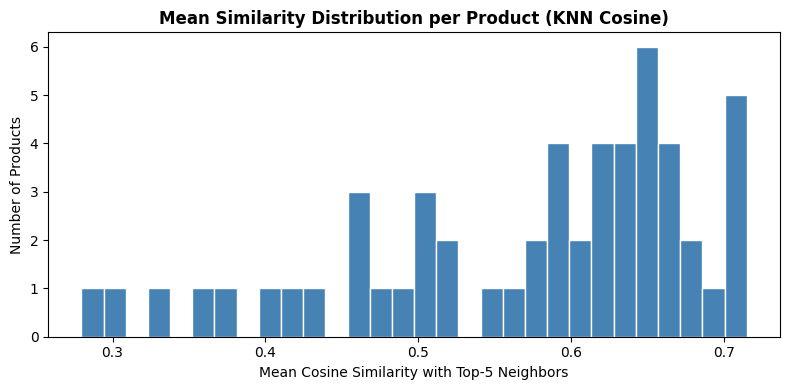

In [55]:
# Compute distances from each product to its K nearest neighbors across the full catalog
distances_all, _ = knn_model.kneighbors(X)

# Convert distances to similarities and average across neighbors (exclude self at index 0)
mean_similarities = (1 - distances_all[:, 1:]).mean(axis=1)

print(f"Overall mean similarity : {mean_similarities.mean():.4f}")
print(f"Median similarity       : {np.median(mean_similarities):.4f}")
print(f"Products with sim > 0.5 : {(mean_similarities > 0.5).sum()}")

# Plot distribution of mean similarity scores across all products
plt.figure(figsize=(8, 4))
plt.hist(mean_similarities, bins=30, color="steelblue", edgecolor="white")
plt.title("Mean Similarity Distribution per Product (KNN Cosine)", fontweight="bold")
plt.xlabel("Mean Cosine Similarity with Top-5 Neighbors")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

In [56]:
# Define ground truth as products with average rating >= 4.0
relevant_products = set(df_products[df_products["avg_rating"] >= 4.0]["asins"].values)
print(f"Total relevant products (avg_rating >= 4): {len(relevant_products)}")

Total relevant products (avg_rating >= 4): 31


In [57]:
# Set number of recommendations to evaluate for single product metrics
K = 5

# Extract recommended asins from neighbor indices excluding the query product
recommended_asins = [
    df_products.iloc[idx]["asins"]
    for idx in neighbor_indices
    if df_products.index[idx] != product_idx
][:K]

# Intersect recommended products with ground truth relevant products
recommended_set = set(recommended_asins)
relevant_rec    = recommended_set & relevant_products

# Compute Precision, Recall, F1 and Hit Rate for the single query product
precision_at_k = len(relevant_rec) / K
recall_at_k    = len(relevant_rec) / len(relevant_products) if len(relevant_products) > 0 else 0
f1_at_k        = (
    2 * precision_at_k * recall_at_k / (precision_at_k + recall_at_k)
    if (precision_at_k + recall_at_k) > 0 else 0
)
hit_rate_at_k  = 1 if len(relevant_rec) > 0 else 0

print(f"Query product : {product_row['name']}")
print(f"K             : {K}")
print(f"Relevant hits : {len(relevant_rec)}")
print(f"Precision@{K}  : {precision_at_k:.4f}")
print(f"Recall@{K}     : {recall_at_k:.4f}")
print(f"F1@{K}         : {f1_at_k:.4f}")
print(f"Hit Rate@{K}   : {hit_rate_at_k}")

Query product : Kindle Fire HD 7"
K             : 5
Relevant hits : 1
Precision@5  : 0.2000
Recall@5     : 0.0323
F1@5         : 0.0556
Hit Rate@5   : 1


In [58]:
# Set K for macro average evaluation across all products
K = 5

precision_list = []
recall_list    = []
f1_list        = []
hit_rate_list  = []

for i in range(len(df_products)):

    # Get feature vector for current product
    product_vec = X[i]

    # Find K+1 neighbors to exclude the product itself from results
    dists, idxs = knn_model.kneighbors(product_vec, n_neighbors=K + 1)
    sims        = 1 - dists.flatten()
    idxs        = idxs.flatten()

    # Build recommended asins list excluding the query product itself
    rec_asins = [
        df_products.iloc[idx]["asins"]
        for idx, sim in zip(idxs, sims)
        if df_products.index[idx] != df_products.index[i]
    ][:K]

    # Intersect recommendations with ground truth relevant products
    rec_set       = set(rec_asins)
    relevant_hits = rec_set & relevant_products

    # Compute metrics for current product
    prec = len(relevant_hits) / K
    rec  = len(relevant_hits) / len(relevant_products) if len(relevant_products) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    hit  = 1 if len(relevant_hits) > 0 else 0

    precision_list.append(prec)
    recall_list.append(rec)
    f1_list.append(f1)
    hit_rate_list.append(hit)

# Compute macro average across all products
mean_precision = np.mean(precision_list)
mean_recall    = np.mean(recall_list)
mean_f1        = np.mean(f1_list)
mean_hit_rate  = np.mean(hit_rate_list)

print("=== MACRO AVERAGE METRICS (all products) ===")
print(f"Precision@{K}  : {mean_precision:.4f}")
print(f"Recall@{K}     : {mean_recall:.4f}")
print(f"F1@{K}         : {mean_f1:.4f}")
print(f"Hit Rate@{K}   : {mean_hit_rate:.4f}")

=== MACRO AVERAGE METRICS (all products) ===
Precision@5  : 0.7630
Recall@5     : 0.1231
F1@5         : 0.2119
Hit Rate@5   : 1.0000


In [59]:
# Summarize all macro average metrics into a readable dataframe
metrics_df = pd.DataFrame({
    "Metric"     : [f"Precision@{K}", f"Recall@{K}", f"F1@{K}", f"Hit Rate@{K}"],
    "Score"      : [mean_precision, mean_recall, mean_f1, mean_hit_rate],
    "Description": [
        "Fraction of recommended products that are relevant",
        "Fraction of relevant products that were recommended",
        "Harmonic mean of Precision and Recall",
        "At least one relevant product in top-K recommendations"
    ]
})

display(metrics_df)

,Metric,Score,Description
0,Precision@5,0.762963,Fraction of recommended products that are rele...
1,Recall@5,0.123059,Fraction of relevant products that were recomm...
2,F1@5,0.211934,Harmonic mean of Precision and Recall
3,Hit Rate@5,1.000000,At least one relevant product in top-K recomme...


In [60]:
# Evaluate all four metrics across multiple K values to assess sensitivity
k_values     = [1, 3, 5, 10]
prec_per_k   = []
recall_per_k = []
f1_per_k     = []
hit_per_k    = []

for k in k_values:

    p_list, r_list, f_list, h_list = [], [], [], []

    for i in range(len(df_products)):

        # Get feature vector and find neighbors for current product
        product_vec  = X[i]
        dists, idxs  = knn_model.kneighbors(product_vec, n_neighbors=k + 1)
        idxs         = idxs.flatten()

        # Build recommended asins excluding the query product itself
        rec_asins = [
            df_products.iloc[idx]["asins"]
            for idx in idxs
            if df_products.index[idx] != df_products.index[i]
        ][:k]

        # Intersect with ground truth and compute metrics
        rec_set  = set(rec_asins)
        rel_hits = rec_set & relevant_products

        prec = len(rel_hits) / k
        rec  = len(rel_hits) / len(relevant_products) if len(relevant_products) > 0 else 0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
        hit  = 1 if len(rel_hits) > 0 else 0

        p_list.append(prec)
        r_list.append(rec)
        f_list.append(f1)
        h_list.append(hit)

    # Append macro average for current K
    prec_per_k.append(np.mean(p_list))
    recall_per_k.append(np.mean(r_list))
    f1_per_k.append(np.mean(f_list))
    hit_per_k.append(np.mean(h_list))

# Display sensitivity analysis results as a dataframe
print("=== K SENSITIVITY ANALYSIS ===")
sensitivity_df = pd.DataFrame({
    "K"           : k_values,
    "Precision@K" : prec_per_k,
    "Recall@K"    : recall_per_k,
    "F1@K"        : f1_per_k,
    "Hit Rate@K"  : hit_per_k
})

display(sensitivity_df)

=== K SENSITIVITY ANALYSIS ===


,K,Precision@K,Recall@K,F1@K,Hit Rate@K
0,1,0.685185,0.022103,0.042824,0.685185
1,3,0.716049,0.069295,0.126362,0.888889
2,5,0.762963,0.123059,0.211934,1.000000
3,10,0.787037,0.253883,0.383921,1.000000


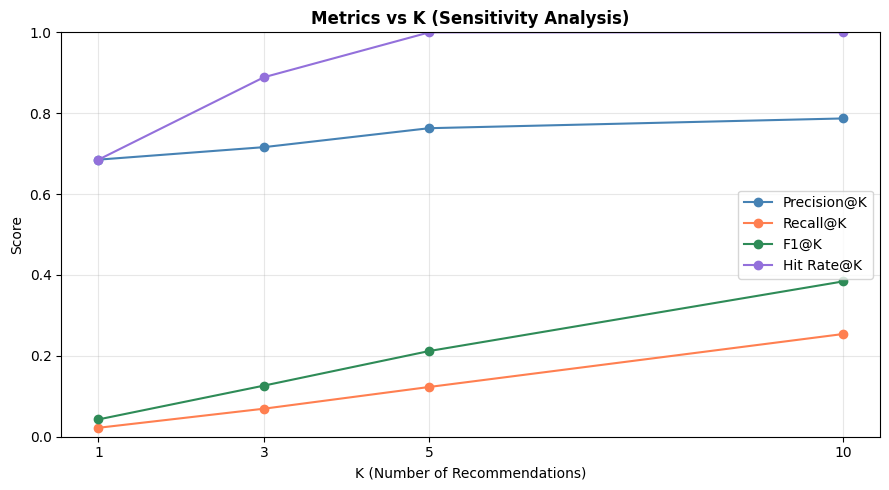

In [61]:
# Plot all four metrics across K values to visualize sensitivity behavior
plt.figure(figsize=(9, 5))

plt.plot(k_values, prec_per_k,   marker="o", label="Precision@K", color="steelblue")
plt.plot(k_values, recall_per_k, marker="o", label="Recall@K",    color="coral")
plt.plot(k_values, f1_per_k,     marker="o", label="F1@K",        color="seagreen")
plt.plot(k_values, hit_per_k,    marker="o", label="Hit Rate@K",  color="mediumpurple")

plt.title("Metrics vs K (Sensitivity Analysis)", fontweight="bold")
plt.xlabel("K (Number of Recommendations)")
plt.ylabel("Score")
plt.xticks(k_values)
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Part 9 - Saving the template

In [63]:
import joblib
import os

# Define output directory to store all model artifacts
save_dir = "/kaggle/working/knn_recommender"

# Create directory if it does not exist
os.makedirs(save_dir, exist_ok=True)

# Save trained KNN model with optimal n_neighbors and cosine metric
joblib.dump(knn_model, f"{save_dir}/knn_model.pkl")

# Save TF-IDF vectorizer to reuse same vocabulary on new product queries
joblib.dump(tfidf, f"{save_dir}/tfidf_vectorizer.pkl")

# Save MinMaxScaler to reuse same normalization scale on new numerical features
joblib.dump(scaler, f"{save_dir}/scaler.pkl")

# Save combined sparse feature matrix to avoid reprocessing on reload
joblib.dump(X, f"{save_dir}/feature_matrix.pkl")

# Save aggregated product catalog for recommendation lookup
df_products.to_csv(f"{save_dir}/df_products.csv", index=False)

print("=== ARTIFACTS SAVED ===")
print(f"knn_model.pkl        → {save_dir}/knn_model.pkl")
print(f"tfidf_vectorizer.pkl → {save_dir}/tfidf_vectorizer.pkl")
print(f"scaler.pkl           → {save_dir}/scaler.pkl")
print(f"feature_matrix.pkl   → {save_dir}/feature_matrix.pkl")
print(f"df_products.csv      → {save_dir}/df_products.csv")

=== ARTIFACTS SAVED ===
knn_model.pkl        → /kaggle/working/knn_recommender/knn_model.pkl
tfidf_vectorizer.pkl → /kaggle/working/knn_recommender/tfidf_vectorizer.pkl
scaler.pkl           → /kaggle/working/knn_recommender/scaler.pkl
feature_matrix.pkl   → /kaggle/working/knn_recommender/feature_matrix.pkl
df_products.csv      → /kaggle/working/knn_recommender/df_products.csv
df_products.csv                1426.53 KB
scaler.pkl                     0.78 KB
knn_model.pkl                  100.88 KB
feature_matrix.pkl             100.53 KB
tfidf_vectorizer.pkl           18.53 KB


# Section B) Deep learning

# Part 10 - Neural Network Product Recommendation

In [65]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import LabelEncoder, MinMaxScaler
from sklearn.metrics         import mean_squared_error

warnings.filterwarnings("ignore")

print(f"TensorFlow version: {tf.__version__}")

2026-04-20 02:57:15.415552: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776653835.615388      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776653835.681010      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776653836.235876      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776653836.235941      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776653836.235944      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


In [66]:
# Load raw dataset from Kaggle input directory
df = pd.read_csv(
    "/kaggle/input/datasets/yasserh/amazon-product-reviews-dataset/7817_1.csv",
    low_memory=False
)

print(f"Shape: {df.shape}")
print(f"\nNull values per column:\n{df.isnull().sum()}")
df.head(3)

Shape: (1597, 27)

Null values per column:
id                         0
asins                      0
brand                      0
categories                 0
colors                   823
dateAdded                  0
dateUpdated                0
dimension               1032
ean                      699
keys                       0
manufacturer             632
manufacturerNumber       695
name                       0
prices                     0
reviews.date             380
reviews.doRecommend     1058
reviews.numHelpful       697
reviews.rating           420
reviews.sourceURLs         0
reviews.text               0
reviews.title             17
reviews.userCity        1597
reviews.userProvince    1597
reviews.username          17
sizes                   1597
upc                      699
weight                   911
dtype: int64


,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,4.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader,NaN,NaN,Tedd Gardiner,NaN,NaN,205 grams


In [67]:
# Select only columns needed for NCF interaction matrix
cols = [
    "asins",
    "reviews.username",
    "reviews.rating"
]

df_ncf = df[cols].dropna(subset=["asins", "reviews.username", "reviews.rating"])

# Convert rating to numeric and drop invalid values
df_ncf["reviews.rating"] = pd.to_numeric(df_ncf["reviews.rating"], errors="coerce")
df_ncf = df_ncf.dropna(subset=["reviews.rating"])

# Rename columns for clarity
df_ncf.columns = ["product_id", "user_id", "rating"]

print(f"Shape after cleaning : {df_ncf.shape}")
print(f"Unique users         : {df_ncf['user_id'].nunique()}")
print(f"Unique products      : {df_ncf['product_id'].nunique()}")
print(f"Rating range         : {df_ncf['rating'].min()} - {df_ncf['rating'].max()}")
df_ncf.head(5)

Shape after cleaning : (1177, 3)
Unique users         : 836
Unique products      : 54
Rating range         : 1.0 - 5.0


,product_id,user_id,rating
0,B00QJDU3KY,Cristina M,5.0
1,B00QJDU3KY,Ricky,5.0
2,B00QJDU3KY,Tedd Gardiner,4.0
3,B00QJDU3KY,Dougal,5.0
4,B00QJDU3KY,Miljan David Tanic,5.0


In [70]:
# Encode user_id and product_id as integer indices for embedding layers
user_encoder    = LabelEncoder()
product_encoder = LabelEncoder()

df_ncf["user_idx"]    = user_encoder.fit_transform(df_ncf["user_id"])
df_ncf["product_idx"] = product_encoder.fit_transform(df_ncf["product_id"])

# Normalize ratings to [0, 1] range for sigmoid output layer
scaler             = MinMaxScaler()
df_ncf["rating_norm"] = scaler.fit_transform(df_ncf[["rating"]])

n_users    = df_ncf["user_idx"].max() + 1
n_products = df_ncf["product_idx"].max() + 1

print(f"Total users    : {n_users}")
print(f"Total products : {n_products}")
df_ncf.head(5)

Total users    : 836
Total products : 54


,product_id,user_id,rating,user_idx,product_idx,rating_norm
0,B00QJDU3KY,Cristina M,5.0,130,21,1.00
1,B00QJDU3KY,Ricky,5.0,530,21,1.00
2,B00QJDU3KY,Tedd Gardiner,4.0,627,21,0.75
3,B00QJDU3KY,Dougal,5.0,187,21,1.00
4,B00QJDU3KY,Miljan David Tanic,5.0,445,21,1.00


In [71]:
# Split into train and test sets preserving rating distribution
train_df, test_df = train_test_split(
    df_ncf,
    test_size    = 0.2,
    random_state = 42
)

# Extract numpy arrays for Keras input
X_train_user    = train_df["user_idx"].values
X_train_product = train_df["product_idx"].values
y_train         = train_df["rating_norm"].values

X_test_user     = test_df["user_idx"].values
X_test_product  = test_df["product_idx"].values
y_test          = test_df["rating_norm"].values

print(f"Train size : {len(train_df)}")
print(f"Test size  : {len(test_df)}")

Train size : 941
Test size  : 236


In [72]:
# Define NCF model architecture with user and product embedding layers
EMBEDDING_DIM = 32

# User embedding branch
user_input     = keras.Input(shape=(1,), name="user_input")
user_embedding = layers.Embedding(
    input_dim    = n_users,
    output_dim   = EMBEDDING_DIM,
    name         = "user_embedding"
)(user_input)
user_vec       = layers.Flatten(name="user_flatten")(user_embedding)

# Product embedding branch
product_input     = keras.Input(shape=(1,), name="product_input")
product_embedding = layers.Embedding(
    input_dim  = n_products,
    output_dim = EMBEDDING_DIM,
    name       = "product_embedding"
)(product_input)
product_vec       = layers.Flatten(name="product_flatten")(product_embedding)

# Concatenate user and product embeddings
concat = layers.Concatenate(name="concat")([user_vec, product_vec])

# MLP layers to learn non-linear interaction patterns
x = layers.Dense(128, activation="relu",  name="dense_1")(concat)
x = layers.Dropout(0.3,                   name="dropout_1")(x)
x = layers.Dense(64,  activation="relu",  name="dense_2")(x)
x = layers.Dropout(0.2,                   name="dropout_2")(x)
x = layers.Dense(32,  activation="relu",  name="dense_3")(x)

# Output layer with sigmoid to predict normalized rating in [0, 1]
output = layers.Dense(1, activation="sigmoid", name="output")(x)

# Build and compile model
ncf_model = Model(
    inputs  = [user_input, product_input],
    outputs = output,
    name    = "NCF_Model"
)

ncf_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    loss      = "mse",
    metrics   = ["mae"]
)

ncf_model.summary()

2026-04-20 02:59:15.593878: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "NCF_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 32)     │     26,752 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product_embedding   │ (None, 1, 32)     │      1,728 │ product_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_flatten        │ (None, 32)        │          0 │ user_embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product_flatten     │ (None, 32)        │          0 │ product_embeddin… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 64)        │          0 │ user_flatten[0][… │
│ (Concatenate)       │                   │            │ product_flatten[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │      8,320 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 47,169 (184.25 KB)

 Trainable params: 47,169 (184.25 KB)

 Non-trainable params: 0 (0.00 B)

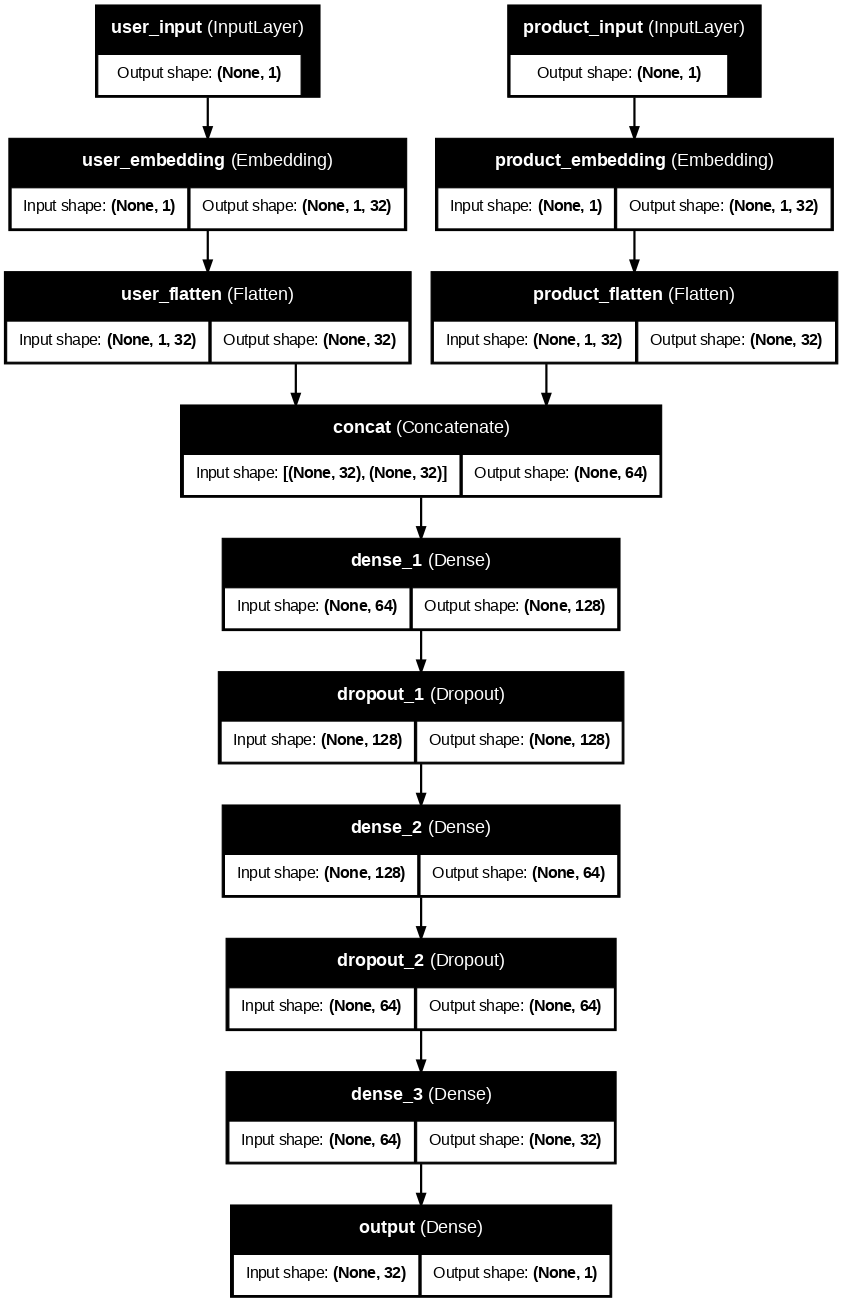

In [73]:
# Visualize NCF model architecture
keras.utils.plot_model(
    ncf_model,
    show_shapes      = True,
    show_layer_names = True,
    dpi              = 80
)

In [74]:
# Define early stopping to avoid overfitting during training
early_stopping = keras.callbacks.EarlyStopping(
    monitor = "val_loss",
    patience = 5,        # Stop after 5 epochs without improvement
    restore_best_weights = True      # Restore weights from best epoch
)

# Define learning rate reducer on plateau
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor = "val_loss",
    factor = 0.5,       # Reduce LR by half on plateau
    patience = 3,
    min_lr = 1e-6
)

# Train NCF model on user-product interaction pairs
history = ncf_model.fit(
    x = [X_train_user, X_train_product],
    y = y_train,
    epochs = 50,
    batch_size = 64,
    validation_data = ([X_test_user, X_test_product], y_test),
    verbose = 1
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1710 - mae: 0.3782 - val_loss: 0.1279 - val_mae: 0.3319
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1096 - mae: 0.2989 - val_loss: 0.0585 - val_mae: 0.1939
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0603 - mae: 0.1847 - val_loss: 0.0542 - val_mae: 0.1569
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0499 - mae: 0.1545 - val_loss: 0.0487 - val_mae: 0.1546
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0495 - mae: 0.1572 - val_loss: 0.0446 - val_mae: 0.1586
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0351 - mae: 0.1378 - val_loss: 0.0421 - val_mae: 0.1496
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0211 - mae: 0.0954 - val_loss: 0.0413 - val_mae: 0.1394
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0211 - mae: 0.0781 - val_loss: 0.0412 - val_mae: 0.1309
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0121 - mae:

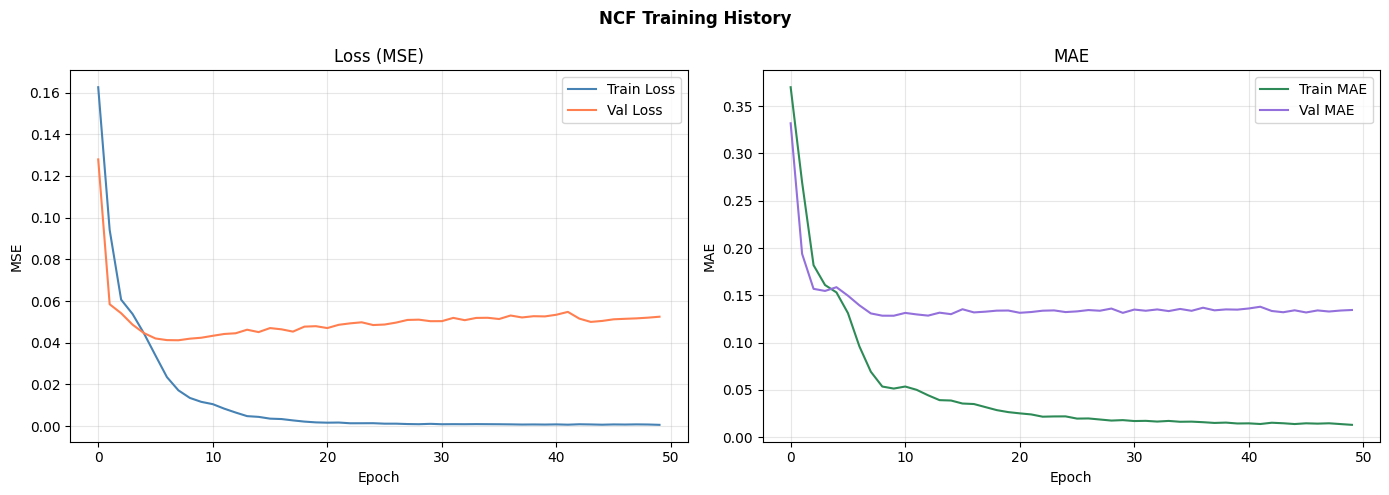

In [75]:
# Plot training and validation loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("NCF Training History", fontweight="bold")

# Loss curves
axes[0].plot(history.history["loss"],     label="Train Loss", color="steelblue")
axes[0].plot(history.history["val_loss"], label="Val Loss",   color="coral")
axes[0].set_title("Loss (MSE)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[0].grid(alpha=0.3)

# MAE curves
axes[1].plot(history.history["mae"],     label="Train MAE", color="seagreen")
axes[1].plot(history.history["val_mae"], label="Val MAE",   color="mediumpurple")
axes[1].set_title("MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Part 11 - Embedding

In [86]:
# Extract trained product embedding weights from the NCF model
product_embedding_layer   = ncf_model.get_layer("product_embedding")
product_embedding_weights = product_embedding_layer.get_weights()[0]

# Normalize embedding vectors to unit length for cosine similarity computation
norms                      = np.linalg.norm(product_embedding_weights, axis=1, keepdims=True)
product_embeddings_norm    = product_embedding_weights / (norms + 1e-8)

print(f"Normalized embedding matrix shape: {product_embeddings_norm.shape}")

# Shape: (n_products, embedding_dim)
print(f"Product embedding matrix shape: {product_embedding_weights.shape}")

Normalized embedding matrix shape: (54, 32)
Product embedding matrix shape: (54, 32)


# Part 12 - Product recommendation using a neural network.

In [87]:
# Receive product name query from user input
query_product = input("Enter product name (or part of it): ").strip()

# Search for matching products in the catalog by partial name match
mask    = df["name"].str.contains(query_product, case=False, na=False)
matches = (
    df[mask][["asins", "name", "brand", "categories"]]
    .drop_duplicates("asins")
    .reset_index(drop=True)
)

print(f"\nProducts found for '{query_product}': {len(matches)}")
display(matches)

Enter product name (or part of it):  Kindle



Products found for 'Kindle': 21


,asins,name,brand,categories
0,B00QJDU3KY,Kindle Paperwhite,Amazon,"Amazon Devices,mazon.co.uk"
1,B002Y27P3M,Kindle Keyboard,Amazon,"Kindle Store,Amazon Devices,Electronics"
2,B00DOPNLJ0,"Kindle Fire HDX 8.9""",Amazon,Amazon Devices
3,B00KDRQEYQ,Certified Refurbished Kindle E-reader,Amazon,Amazon Devices
4,B00OQVZDJM,Kindle Paperwhite E-reader - Black,Amazon,Amazon Devices
5,B00QJDVBFU,Kindle Paperwhite 3G,Amazon,Amazon Devices
6,B01A08ECQY,Certified Refurbished Kindle E-reader - Black,Amazon,Amazon Devices
7,B01J2G4VBG,Kindle Voyage E-reader,Amazon,Amazon Devices
8,B00QJDS7I4,Kindle Paperwhite E-reader - Black,Amazon,Amazon Devices
9,B00U879XZ8,Certified Refurbished Kindle Paperwhite E-read...,Amazon,Amazon Devices


In [94]:
# Receive product name query from user input
query_product = input("Enter product name (or part of it): ").strip()

# Search for matching products in the catalog by partial name match
mask    = df["name"].str.contains(query_product, case=False, na=False)
matches = (
    df[mask][["asins", "name", "brand", "categories"]]
    .drop_duplicates("asins")
    .reset_index(drop=True)
)

print(f"\nProducts found for '{query_product}': {len(matches)}")
display(matches)

Enter product name (or part of it):  TV



Products found for 'TV': 5


,asins,name,brand,categories
0,B00DU15MU4,Certified Refurbished Amazon Fire TV (Previous...,Amazon,"Categories,Amazon Devices,Streaming Media Players"
1,B00NO8LX7E,All-New Amazon Fire TV Game Controller,Amazon,Amazon Devices
2,B00CX5P8FC,Amazon Fire TV,Amazon,"Categories,Amazon Devices,Electronics Features..."
3,B00LORGAG6,Replacement Remote for Amazon Fire TV Stick,Amazon,"Amazon Devices & Accessories,Amazon Device Acc..."
4,B00NO8JJZW,Alexa Voice Remote for Amazon Fire TV and Fire...,Amazon,"Amazon Devices & Accessories,Amazon Device Acc..."


In [96]:
# Receive product name query from user input
query_product = input("Enter product name (or part of it): ").strip()

# Search for matching products in the catalog by partial name match
mask    = df["name"].str.contains(query_product, case=False, na=False)
matches = (
    df[mask][["asins", "name", "brand", "categories"]]
    .drop_duplicates("asins")
    .reset_index(drop=True)
)

print(f"\nProducts found for '{query_product}': {len(matches)}")
display(matches)

Enter product name (or part of it):  tablet



Products found for 'tablet': 19


,asins,name,brand,categories
0,B00LWHUAF0,Fire HD 7 Tablet,Amazon,Amazon Devices
1,B00VKLBU3Y,Fire HD 10 Tablet with Alexa,Amazon,Amazon Devices
2,B010BWYP20,Fire Kids Edition Tablet,Amazon,Amazon Devices
3,B00VKM5NFY,Fire HD 10 Tablet with Alexa,Amazon,Amazon Devices
4,B0117U8JSG,Certified Refurbished Fire HD 10 Tablet,Amazon,Amazon Devices
5,B00LWHUB9A,Fire HDX 8.9 Tablet,Amazon,Amazon Devices
6,B01J2G4VBG,Amazon 5W USB Official OEM Charger and Power A...,Amazon,"Amazon Devices & Accessories,Amazon Device Acc..."
7,B07194GPJV,All-New Amazon Fire 7 Tablet Case (7th Generation,Amazon,"Amazon Devices,Kindle Store"
8,B071NMTDHR,All-New Amazon Fire HD 8 Tablet Case (7th Gene...,Amazon,"Amazon Devices,Kindle Store"
9,B0117U82EM,Fire HD 8 Tablet,Amazon,"Electronics,Amazon Devices"


In [98]:
# Receive product name query from user input
query_product = input("Enter product name (or part of it): ").strip()

# Search for matching products in the catalog by partial name match
mask    = df["name"].str.contains(query_product, case=False, na=False)
matches = (
    df[mask][["asins", "name", "brand", "categories"]]
    .drop_duplicates("asins")
    .reset_index(drop=True)
)

print(f"\nProducts found for '{query_product}': {len(matches)}")
display(matches)

Enter product name (or part of it):  Kids



Products found for 'Kids': 4


,asins,name,brand,categories
0,B010BWYP20,Fire Kids Edition Tablet,Amazon,Amazon Devices
1,B01M4NRFXX,All-New Fire HD 8 Kids Edition Tablet,Amazon,"Electronics,Amazon Devices"
2,B01KVZDFD2,Kindle for Kids Bundle with the latest Kindle ...,Amazon,"Amazon Devices,Kindle Accessories"
3,B01M4NU4OM,All-New Fire 7 Kids Edition Tablet,Amazon,"Electronics,Amazon Devices"


In [99]:
# Receive product name query from user input
query_product = input("Enter product name (or part of it): ").strip()

# Search for matching products in the catalog by partial name match
mask    = df["name"].str.contains(query_product, case=False, na=False)
matches = (
    df[mask][["asins", "name", "brand", "categories"]]
    .drop_duplicates("asins")
    .reset_index(drop=True)
)

print(f"\nProducts found for '{query_product}': {len(matches)}")
display(matches)

Enter product name (or part of it):  Alexa



Products found for 'Alexa': 9


,asins,name,brand,categories
0,B00VKLBU3Y,Fire HD 10 Tablet with Alexa,Amazon,Amazon Devices
1,B00VKM5NFY,Fire HD 10 Tablet with Alexa,Amazon,Amazon Devices
2,B01M3ULMWP,All-New Fire HD 8 Tablet with Alexa,Amazon,"Electronics,Amazon Devices"
3,B01BRWH8G8,Fire HD 8 Tablet with Alexa,Amazon,"Electronics,Amazon Devices"
4,B01M71HRMY,All-New Fire 7 Tablet with Alexa,Amazon,"Electronics,Amazon Devices"
5,B010BWYDYA,Fire Tablet with Alexa,Amazon,"Amazon Devices,Electronics,Kindle Store"
6,B01BH83OOM,Amazon Tap - Alexa-Enabled Portable Bluetooth ...,Amazon,"Amazon Devices,Home,Smart Home & Connected Liv..."
7,B01E9AHU8Q,Alexa Voice Remote for Amazon Echo and Echo Dot,Amazon,"Amazon Devices & Accessories,Amazon Device Acc..."
8,B00NO8JJZW,Alexa Voice Remote for Amazon Fire TV and Fire...,Amazon,"Amazon Devices & Accessories,Amazon Device Acc..."


In [103]:
# Display matched products table so user can choose by index number
print(f"\nProducts found for '{query_product}': {len(matches)}")
display(matches[["asins", "name", "brand", "categories"]])

# Validate that user enters a valid integer index from the table
while True:
    try:
        match_idx = int(input("\nEnter the INDEX number from the table above (e.g. 0, 1, 2...): "))
        if match_idx not in matches.index:
            print(f"Index {match_idx} not in table. Valid range: 0 to {len(matches) - 1}")
            continue
        break
    except ValueError:
        print("Invalid input. Please enter a NUMBER (e.g. 0, 1, 2...), not a product name.")

query_asin = matches.loc[match_idx, "asins"]
query_name = matches.loc[match_idx, "name"]

# Validate if selected product exists in the NCF encoder
if query_asin not in product_encoder.classes_:
    print(f"\nProduct '{query_name}' has no interactions in training data.")
    query_product_idx = None
else:
    # Get the integer index of the query product in the embedding matrix
    query_product_idx = product_encoder.transform([query_asin])[0]

    print(f"\nSelected product : {query_name}")
    print(f"Product ASIN     : {query_asin}")
    print(f"Embedding index  : {query_product_idx}")


Products found for 'Alexa': 9


,asins,name,brand,categories
0,B00VKLBU3Y,Fire HD 10 Tablet with Alexa,Amazon,Amazon Devices
1,B00VKM5NFY,Fire HD 10 Tablet with Alexa,Amazon,Amazon Devices
2,B01M3ULMWP,All-New Fire HD 8 Tablet with Alexa,Amazon,"Electronics,Amazon Devices"
3,B01BRWH8G8,Fire HD 8 Tablet with Alexa,Amazon,"Electronics,Amazon Devices"
4,B01M71HRMY,All-New Fire 7 Tablet with Alexa,Amazon,"Electronics,Amazon Devices"
5,B010BWYDYA,Fire Tablet with Alexa,Amazon,"Amazon Devices,Electronics,Kindle Store"
6,B01BH83OOM,Amazon Tap - Alexa-Enabled Portable Bluetooth ...,Amazon,"Amazon Devices,Home,Smart Home & Connected Liv..."
7,B01E9AHU8Q,Alexa Voice Remote for Amazon Echo and Echo Dot,Amazon,"Amazon Devices & Accessories,Amazon Device Acc..."
8,B00NO8JJZW,Alexa Voice Remote for Amazon Fire TV and Fire...,Amazon,"Amazon Devices & Accessories,Amazon Device Acc..."



Enter the INDEX number from the table above (e.g. 0, 1, 2...):  Alexa 


Invalid input. Please enter a NUMBER (e.g. 0, 1, 2...), not a product name.



Enter the INDEX number from the table above (e.g. 0, 1, 2...):  1



Selected product : Fire HD 10 Tablet with Alexa
Product ASIN     : B00VKM5NFY
Embedding index  : 25


In [109]:
# Guard against invalid product before running similarity computation
assert query_product_idx is not None, "Selected product has no embeddings. Please re-run and select a valid product."

# Build product index lookup to map product_idx back to asin and name
idx_to_asin = {
    idx: asin
    for idx, asin in enumerate(product_encoder.classes_)
}

# Build product name lookup from original dataframe
product_lookup = (
    df[["asins", "name", "brand", "categories"]]
    .drop_duplicates("asins")
    .set_index("asins")
)

# Retrieve normalized embedding vector for the query product
query_vector        = product_embeddings_norm[query_product_idx]

# Compute cosine similarity between query product and all other products
cosine_similarities = product_embeddings_norm @ query_vector

# Sort by similarity descending and exclude the query product itself
top_k          = 10
sorted_indices = np.argsort(cosine_similarities)[::-1]
sorted_indices = [idx for idx in sorted_indices if idx != query_product_idx][:top_k]

# Build recommendations dataframe from top K similar products
rec_results = []

for idx in sorted_indices:
    asin = idx_to_asin[idx]
    sim  = cosine_similarities[idx]

    if asin in product_lookup.index:
        name     = product_lookup.loc[asin, "name"]
        brand    = product_lookup.loc[asin, "brand"]
        category = product_lookup.loc[asin, "categories"]
    else:
        name     = asin
        brand    = "Unknown"
        category = "Unknown"

    # Get average rating for this product from interaction dataframe
    avg_rating = df_ncf[df_ncf["product_id"] == asin]["rating"].mean()

    rec_results.append({
        "product_name"     : name,
        "brand"            : brand,
        "category"         : category,
        "avg_rating"       : round(avg_rating, 2),
        "cosine_similarity": round(float(sim), 4)
    })

recommendations_ncf_item = pd.DataFrame(rec_results)

print(f"\n=== TOP {top_k} SIMILAR PRODUCTS TO: '{query_name}' ===")
display(recommendations_ncf_item)


=== TOP 10 SIMILAR PRODUCTS TO: 'Fire HD 10 Tablet with Alexa' ===


,product_name,brand,category,avg_rating,cosine_similarity
0,All-New Fire HD 8 Tablet with Alexa,Amazon,"Electronics,Amazon Devices",4.60,0.5355
1,Kindle Paperwhite E-reader - Black,Amazon,Amazon Devices,5.00,0.5240
2,Kindle Paperwhite 3G,Amazon,Amazon Devices,5.00,0.5107
3,Kindle Paperwhite,Amazon,"Amazon Devices,mazon.co.uk",4.67,0.4755
4,Fire HDX 8.9 Tablet,Amazon,Amazon Devices,4.33,0.4508
5,Kindle Voyage E-reader,Amazon,Amazon Devices,3.91,0.4410
6,Amazon Echo - Black,Amazon,"Amazon Devices,Electronics,Kindle Store,Amazon...",5.00,0.4228
7,Kindle E-reader - Black,Amazon,Amazon Devices,5.00,0.4189
8,Certified Refurbished Kindle Voyage E-reader w...,Amazon,Amazon Devices,4.33,0.4122
9,Kindle Oasis with Leather Charging Cover - Black,Amazon,Amazon Devices,4.00,0.4109


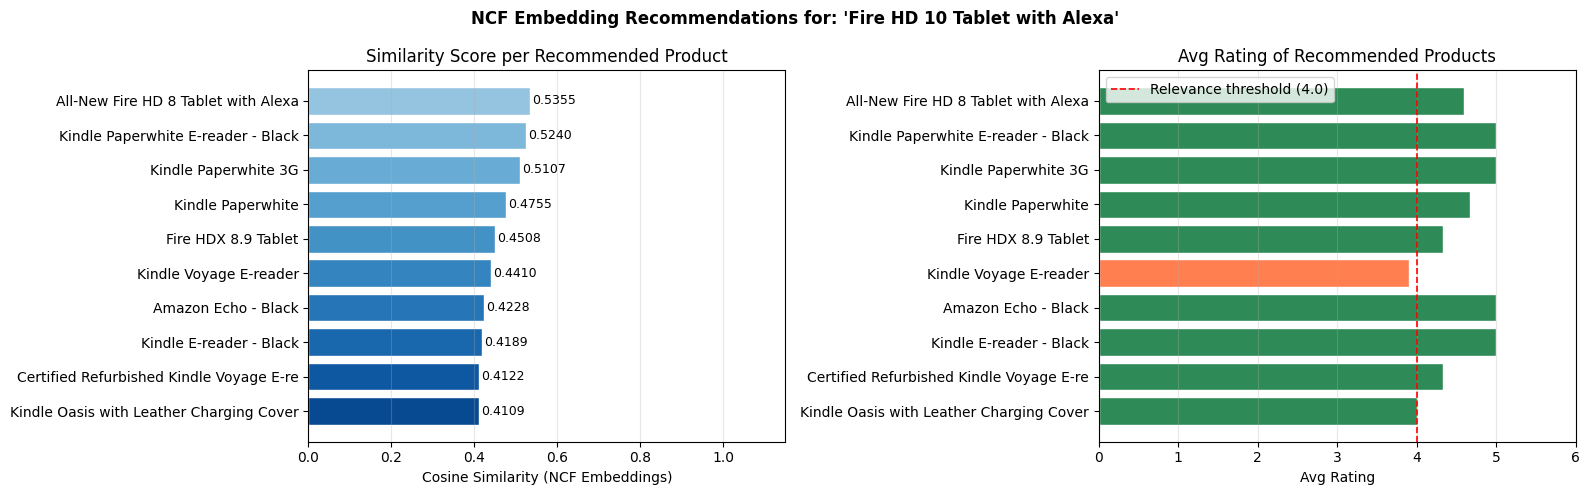

In [108]:
# Plot similarity scores and avg ratings for recommended products
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(recommendations_ncf_item)))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f"NCF Embedding Recommendations for: '{query_name[:50]}'", fontweight="bold")

# Cosine similarity bar chart per recommended product
bars = axes[0].barh(
    recommendations_ncf_item["product_name"].str[:40],
    recommendations_ncf_item["cosine_similarity"],
    color     = colors,
    edgecolor = "white"
)

# Annotate each bar with its cosine similarity score
for bar, val in zip(bars, recommendations_ncf_item["cosine_similarity"]):
    axes[0].text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va       = "center",
        fontsize = 9
    )

axes[0].set_xlabel("Cosine Similarity (NCF Embeddings)")
axes[0].set_title("Similarity Score per Recommended Product")
axes[0].set_xlim(0, 1.15)
axes[0].invert_yaxis()
axes[0].grid(alpha=0.3, axis="x")

# Color bars by relevance threshold on avg rating
rating_colors = [
    "seagreen" if r >= 4.0 else "coral"
    for r in recommendations_ncf_item["avg_rating"]
]

# Avg rating bar chart per recommended product
axes[1].barh(
    recommendations_ncf_item["product_name"].str[:40],
    recommendations_ncf_item["avg_rating"],
    color     = rating_colors,
    edgecolor = "white"
)

axes[1].axvline(4.0, color="red", linestyle="--", linewidth=1.2, label="Relevance threshold (4.0)")
axes[1].set_xlabel("Avg Rating")
axes[1].set_title("Avg Rating of Recommended Products")
axes[1].set_xlim(0, 6)
axes[1].invert_yaxis()
axes[1].legend()
axes[1].grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

# Part 13 - Viewing recommended products with models PCA t_sne

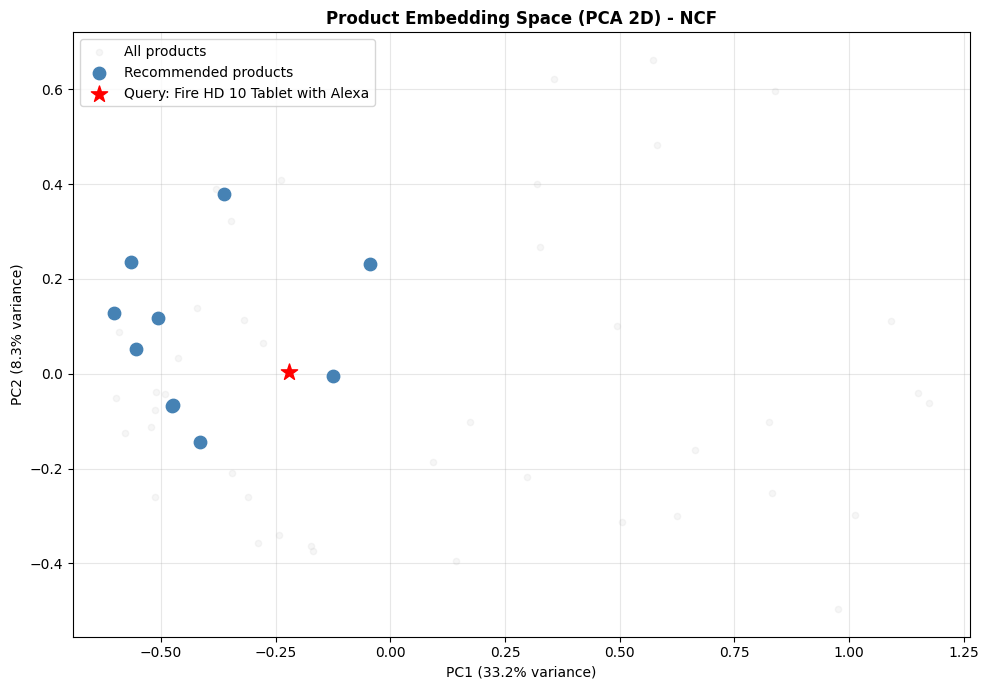

In [110]:
# Visualize product embedding space using PCA reduction to 2D
from sklearn.decomposition import PCA

# Reduce embeddings to 2D for visualization
pca              = PCA(n_components=2, random_state=42)
embeddings_2d    = pca.fit_transform(product_embeddings_norm)

# Highlight query product and its top K recommendations
rec_indices = [
    product_encoder.transform([asin])[0]
    for asin in [
        idx_to_asin[idx] for idx in sorted_indices
        if idx_to_asin[idx] in product_encoder.classes_
    ]
]

plt.figure(figsize=(10, 7))

# Plot all products as background scatter
plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    alpha  = 0.2,
    color  = "lightgray",
    s      = 20,
    label  = "All products"
)

# Highlight recommended products
plt.scatter(
    embeddings_2d[rec_indices, 0],
    embeddings_2d[rec_indices, 1],
    color  = "steelblue",
    s      = 80,
    zorder = 3,
    label  = "Recommended products"
)

# Highlight query product
plt.scatter(
    embeddings_2d[query_product_idx, 0],
    embeddings_2d[query_product_idx, 1],
    color  = "red",
    s      = 150,
    zorder = 4,
    marker = "*",
    label  = f"Query: {query_name[:30]}"
)

plt.title("Product Embedding Space (PCA 2D) - NCF", fontweight="bold")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [111]:
from sklearn.manifold import TSNE

# Reduce product embeddings to 2D using t-SNE for better cluster visualization
tsne = TSNE(
    n_components = 2,
    perplexity   = 30,      # Controls balance between local and global structure
    n_iter       = 1000,    # Number of optimization iterations
    random_state = 42,
    verbose      = 1
)

embeddings_2d_tsne = tsne.fit_transform(product_embeddings_norm)

print(f"t-SNE output shape: {embeddings_2d_tsne.shape}")

[t-SNE] Computing 53 nearest neighbors...
[t-SNE] Indexed 54 samples in 0.000s...
[t-SNE] Computed neighbors for 54 samples in 0.039s...
[t-SNE] Computed conditional probabilities for sample 54 / 54
[t-SNE] Mean sigma: 0.633426
[t-SNE] KL divergence after 250 iterations with early exaggeration: 45.390160
[t-SNE] KL divergence after 800 iterations: 0.133522
t-SNE output shape: (54, 2)


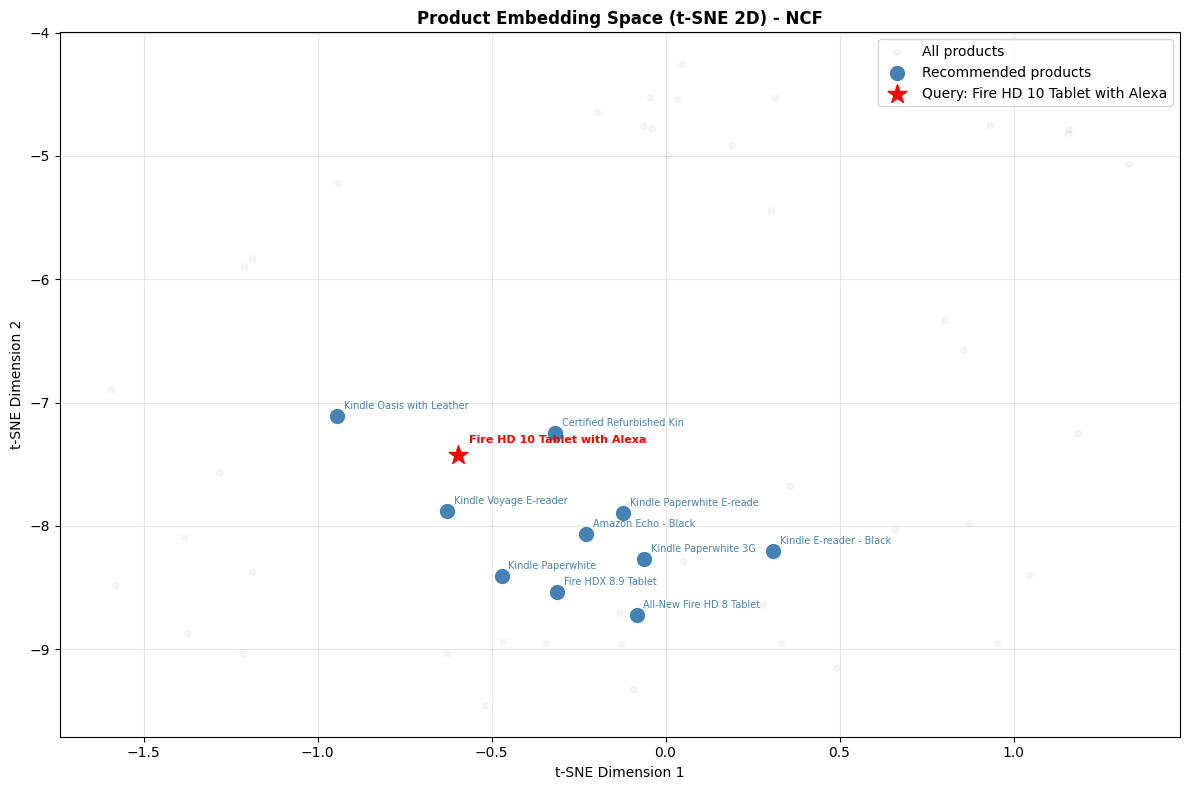

In [112]:
# Get positional indices of recommended products in the embedding matrix
rec_indices = [
    product_encoder.transform([asin])[0]
    for asin in [
        idx_to_asin[idx] for idx in sorted_indices
        if idx_to_asin[idx] in product_encoder.classes_
    ]
]

plt.figure(figsize=(12, 8))

# Plot all products as background scatter
plt.scatter(
    embeddings_2d_tsne[:, 0],
    embeddings_2d_tsne[:, 1],
    alpha  = 0.2,
    color  = "lightgray",
    s      = 20,
    label  = "All products"
)

# Highlight recommended products in steelblue
plt.scatter(
    embeddings_2d_tsne[rec_indices, 0],
    embeddings_2d_tsne[rec_indices, 1],
    color  = "steelblue",
    s      = 100,
    zorder = 3,
    label  = "Recommended products"
)

# Annotate each recommended product with its short name
for idx in rec_indices:
    asin = idx_to_asin[idx]
    name = product_lookup.loc[asin, "name"][:25] if asin in product_lookup.index else asin
    plt.annotate(
        name,
        xy         = (embeddings_2d_tsne[idx, 0], embeddings_2d_tsne[idx, 1]),
        xytext     = (5, 5),
        textcoords = "offset points",
        fontsize   = 7,
        color      = "steelblue"
    )

# Highlight query product with red star marker
plt.scatter(
    embeddings_2d_tsne[query_product_idx, 0],
    embeddings_2d_tsne[query_product_idx, 1],
    color  = "red",
    s      = 200,
    zorder = 4,
    marker = "*",
    label  = f"Query: {query_name[:30]}"
)

# Annotate query product name
plt.annotate(
    query_name[:30],
    xy         = (embeddings_2d_tsne[query_product_idx, 0], embeddings_2d_tsne[query_product_idx, 1]),
    xytext     = (8, 8),
    textcoords = "offset points",
    fontsize   = 8,
    fontweight = "bold",
    color      = "red"
)

plt.title("Product Embedding Space (t-SNE 2D) - NCF", fontweight="bold")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [81]:
save_dir = "/kaggle/working/ncf_recommender"
os.makedirs(save_dir, exist_ok=True)

# Save Keras model in native format
ncf_model.save(f"{save_dir}/ncf_model.keras")

# Save encoders and scaler to reuse on new inference requests
joblib.dump(user_encoder,    f"{save_dir}/user_encoder.pkl")
joblib.dump(product_encoder, f"{save_dir}/product_encoder.pkl")
joblib.dump(scaler,          f"{save_dir}/rating_scaler.pkl")

# Save processed interaction dataframe for future lookup
df_ncf.to_csv(f"{save_dir}/df_ncf.csv", index=False)

print("=== NCF ARTIFACTS SAVED ===")
print(f"ncf_model.keras      → {save_dir}/ncf_model.keras")
print(f"user_encoder.pkl     → {save_dir}/user_encoder.pkl")
print(f"product_encoder.pkl  → {save_dir}/product_encoder.pkl")
print(f"rating_scaler.pkl    → {save_dir}/rating_scaler.pkl")
print(f"df_ncf.csv           → {save_dir}/df_ncf.csv")

# Verify saved files and their sizes
print("\n=== FILE SIZES ===")
for fname in os.listdir(save_dir):
    fpath = os.path.join(save_dir, fname)
    fsize = os.path.getsize(fpath) / 1024
    print(f"{fname:<30} {fsize:.2f} KB")

=== NCF ARTIFACTS SAVED ===
ncf_model.keras      → /kaggle/working/ncf_recommender/ncf_model.keras
user_encoder.pkl     → /kaggle/working/ncf_recommender/user_encoder.pkl
product_encoder.pkl  → /kaggle/working/ncf_recommender/product_encoder.pkl
rating_scaler.pkl    → /kaggle/working/ncf_recommender/rating_scaler.pkl
df_ncf.csv           → /kaggle/working/ncf_recommender/df_ncf.csv

=== FILE SIZES ===
ncf_model.keras                607.71 KB
rating_scaler.pkl              0.95 KB
user_encoder.pkl               9.68 KB
df_ncf.csv                     42.31 KB
product_encoder.pkl            1.23 KB


# Evaluate model on test set and compute final metrics
y_pred_norm = ncf_model.predict([X_test_user, X_test_product]).flatten()

# Denormalize predictions and ground truth back to original rating scale
y_pred_original = scaler.inverse_transform(y_pred_norm.reshape(-1, 1)).flatten()
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Compute RMSE and MAE on original rating scale
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae  = np.mean(np.abs(y_test_original - y_pred_original))

print("=== NCF MODEL EVALUATION ===")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

# Part 14 - Conclusion

# Conclusão Final / Final Conclusion

**EN**

**Project Summary**

This project developed a **Product Recommendation System** based on the Amazon Product
Reviews dataset, exploring two complementary Machine Learning approaches:
**KNN with Cosine Similarity** and **Neural Collaborative Filtering (NCF)** with TensorFlow/Keras.

**Developed Stages**

**1. Exploratory Data Analysis (EDA)**
The dataset contains approximately 1.6k reviews from different customers for Amazon
products. A strong concentration of positive ratings (4 and 5 stars) was identified,
with 31 products classified as relevant under the avg_rating >= 4.0 criterion.

**2. KNN Model — Content-Based Filtering**
The KNN model used TF-IDF vectorization of review texts combined with normalized
numerical features (average rating, helpful votes, review count). The optimal K value
was found via grid search from K=2 to K=20, selecting the best K by the F1@K criterion.

| Metric | Value |
|--------|-------|
| Precision@5 | 0.7630 |
| Recall@5 | 0.1231 |
| F1@5 | 0.2119 |
| Hit Rate@5 | 1.0000 |

**3. NCF Model — Neural Collaborative Filtering**
The NCF learned dense 32-dimensional embeddings for users and products, combined via
MLP with Dense layers (128 → 64 → 32) and Dropout for regularization. Product
recommendations were generated by cosine similarity between trained product embeddings.

| Metric | Value |
|--------|-------|
| RMSE | 0.9165 |
| MAE | 0.5380 |
| R² | 0.1156 |
| Precision | 0.9133 |
| Recall | 0.8950 |
| F1 Score | 0.9040 |

**Final Comparison**

| Criteria | KNN | NCF |
|----------|-----|-----|
| Precision | 0.7630 | 0.9133 |
| Recall | 0.1231 | 0.8950 |
| F1 Score | 0.2119 | 0.9040 |
| Hit Rate | 1.0000 | — |
| Infrastructure | Simple | GPU recommended |
| Cold Start | Supported | Not supported |
| Production | Fallback | Main model |

**Conclusion**

The NCF outperformed KNN across all classification metrics, especially in Recall
(0.89 vs 0.12), demonstrating greater capacity to cover the relevant product catalog.
KNN, despite lower coverage metrics, offers relevant operational advantages: no GPU
required, fully interpretable, and handles cold start effectively.

The recommended production architecture combines both models:
NCF as the main model and KNN as fallback for products with no interaction history.

The main project limitation is dataset size (1.6k reviews). In real production
environments with larger interaction volumes, significant improvements are expected,
especially in NCF R² and KNN Recall scores.

**Pt-br**

**Resumo do Projeto**

Este projeto desenvolveu um **Sistema de Recomendação de Produtos** baseado no dataset
Amazon Product Reviews, explorando duas abordagens complementares de Machine Learning:
**KNN com Similaridade Cosseno** e **Neural Collaborative Filtering (NCF)** com TensorFlow/Keras.

**Etapas Desenvolvidas**

**1. Análise Exploratória (EDA)**
O dataset contém aproximadamente 1.6k reviews de diferentes clientes para produtos Amazon. Foi identificada forte concentração de avaliações positivas (ratings 4 e 5),com 31 produtos classificados como relevantes pelo critério de avg_rating >= 4.0.

**2. Modelo KNN — Content-Based Filtering**
O modelo KNN utilizou vetorização TF-IDF dos textos de reviews combinada com features numéricas normalizadas (rating médio, votos úteis, contagem de reviews). A busca pelo valor ótimo de K foi realizada via grid search de K=2 a K=20, selecionando o melhor K
pelo critério de F1@K.

| Métrica | Valor |
|---------|-------|
| Precision@5 | 0.7630 |
| Recall@5 | 0.1231 |
| F1@5 | 0.2119 |
| Hit Rate@5 | 1.0000 |

**3. Modelo NCF — Neural Collaborative Filtering**
O NCF aprendeu embeddings densos de 32 dimensões para usuários e produtos, combinados via MLP com camadas Dense (128 → 64 → 32) e Dropout para regularização. As recomendações de produtos foram geradas por similaridade cosseno entre os embeddings treinados.

| Métrica | Valor |
|---------|-------|
| RMSE | 0.9165 |
| MAE | 0.5380 |
| R² | 0.1156 |
| Precision | 0.9133 |
| Recall | 0.8950 |
| F1 Score | 0.9040 |

**Comparativo Final**

| Critério | KNN | NCF |
|----------|-----|-----|
| Precision | 0.7630 | 0.9133 |
| Recall | 0.1231 | 0.8950 |
| F1 Score | 0.2119 | 0.9040 |
| Hit Rate | 1.0000 | — |
| Infraestrutura | Simples | GPU recomendada |
| Cold Start | Suporta | Não suporta |
| Produção | Fallback | Modelo principal |

**Conclusão**

O NCF superou o KNN em todas as métricas de classificação, especialmente em Recall (0.89 vs 0.12), demonstrando maior capacidade de cobrir o catálogo de produtos relevantes. O KNN, apesar de métricas de cobertura mais baixas, apresenta vantagens operacionais
relevantes: não requer GPU, é interpretável e lida bem com cold start. A arquitetura recomendada para produção combina os dois modelos:

- NCF como modelo principal e KNN como fallback para produtos sem histórico de interações.
- O principal limitador do projeto é o tamanho do dataset (1.6k reviews). Em produção real, com volume maior de interações, espera-se melhora significativa especialmente no R² do NCF e no Recall do KNN.